In [ ]:
!pip install scikit-learn pyarrow fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report

start_time = time.perf_counter()

In [ ]:
seed = 1234
np.random.seed(seed)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

train_path = "/content/drive/MyDrive/CS-178-Movie-Project-main/train.parquet"
test_path = "/content/drive/MyDrive/CS-178-Movie-Project-main/test.parquet"

train_frame = pd.read_parquet(train_path)
test_frame = pd.read_parquet(test_path)


Mounted at /content/drive


In [ ]:
print(train_frame.shape)
print(test_frame.shape)

(25000, 2)
(25000, 2)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

X_text_tr, X_text_val,y_train,y_val = train_test_split(
    train_frame["text"],
    train_frame["label"],
    test_size = 0.25,
    random_state = seed,
    stratify = train_frame["label"],
    shuffle = True
)

X_test = test_frame["text"]
y_test = test_frame["label"].values

vectorize = TfidfVectorizer(
    max_features = 20000,
    ngram_range=(1,2),
    sublinear_tf = True
)


In [ ]:
X_train = vectorize.fit_transform(X_text_tr)
X_val = vectorize.transform(X_text_val)
X_test = vectorize.transform(X_test)

y_train = y_train.values
y_val = y_val.values

In [ ]:
X_train.shape
X_val.shape
X_test.shape


(25000, 20000)

# Training the NN Model to find lowest Error for best result

In [ ]:
parameters = {
  "hidden_layer_sizes": [(64,),(128,),(256,)],
  "learning_rate_init": [0.001,0.005,0.01,0.05],
  "alpha": [0.0001,0.001,0.01,0.1],
  "solver": ["sgd","adam"],
  "batch_size": [128,256,512]
}

In [ ]:
all_models = []

mlp = MLPClassifier(
    activation = 'relu',
    max_iter = 100,
    random_state =seed,
    early_stopping = True,
    n_iter_no_change =10,
    validation_fraction=0.1,
    tol = 0.001
)

model_search = RandomizedSearchCV(
    estimator = mlp,
    param_distributions = parameters,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=seed,
    return_train_score=True,
    refit=True,
)
model_search.fit(X_train,y_train)

best_fit = model_search.best_estimator_
best_configuration = model_search.best_params_
best_cv_acc = model_search.best_score_

train_acc = model_search.score(X_train,y_train)
val_acc = best_fit.score(X_val,y_val)
test_acc = best_fit.score(X_test,y_test)
print(f"VAL ACCURACY:{val_acc}")
print(f"TEST ACCURACY :{test_acc}")
results = pd.DataFrame(model_search.cv_results_).sort_values(
    "mean_test_score",ascending = False
).reset_index(drop=True)

for x, row in results.iterrows():
  all_models.append([
      x+1,
      row["param_hidden_layer_sizes"],
      row["param_learning_rate_init"],
      row["param_alpha"],
      row["param_solver"],
      row["mean_train_score"] if "mean_train_score" in results.columns else None,
      row["mean_test_score"]
  ])
f_result = pd.DataFrame(
    all_models,
    columns = ["Run #:","Layer #:","LR #:","Alpha #:","Solver type:","Train ACC:","Val ACC:"]
)

print(f_result)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
VAL ACCURACY:0.896
TEST ACCURACY :0.89488
    Run #: Layer #:  LR #:  Alpha #: Solver type:  Train ACC:  Val ACC:
0        1   (128,)  0.005    0.0100         adam    0.965973  0.897653
1        2   (256,)  0.001    0.0100         adam    0.975813  0.896693
2        3   (128,)  0.005    0.0010         adam    0.982933  0.894027
3        4   (256,)  0.050    0.1000          sgd    0.968747  0.893867
4        5    (64,)  0.050    0.0001          sgd    0.979680  0.893867
5        6   (128,)  0.050    0.0010          sgd    0.971093  0.893813
6        7   (128,)  0.001    0.1000         adam    0.968107  0.893707
7        8   (256,)  0.005    0.0001         adam    0.977600  0.891520
8        9   (256,)  0.010    0.0001         adam    0.978320  0.889813
9       10   (256,)  0.050    0.0001         adam    0.973360  0.888533
10      11    (64,)  0.050    0.0001         adam    0.977680  0.887253
11      12   (128,)  0.005    0.0

In [ ]:
print(f"BEST CONFIGURATION: {best_configuration}")
print(f"Test error rate: {1-test_acc}")

BEST CONFIGURATION: {'solver': 'adam', 'learning_rate_init': 0.005, 'hidden_layer_sizes': (128,), 'batch_size': 256, 'alpha': 0.01}
Test error rate: 0.10511999999999999


In [ ]:
y_pred_val = best_fit.predict(X_val)
y_pred_test = best_fit.predict(X_test)
print("Val Report")
print(classification_report(y_val,y_pred_val,target_names= ["Negative","Positive"]))
print("Test Report")
print(classification_report(y_test,y_pred_test,target_names=["Negative","Positive"]))

Val Report
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      3125
    Positive       0.89      0.90      0.90      3125

    accuracy                           0.90      6250
   macro avg       0.90      0.90      0.90      6250
weighted avg       0.90      0.90      0.90      6250

Test Report
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     12500
    Positive       0.89      0.90      0.90     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



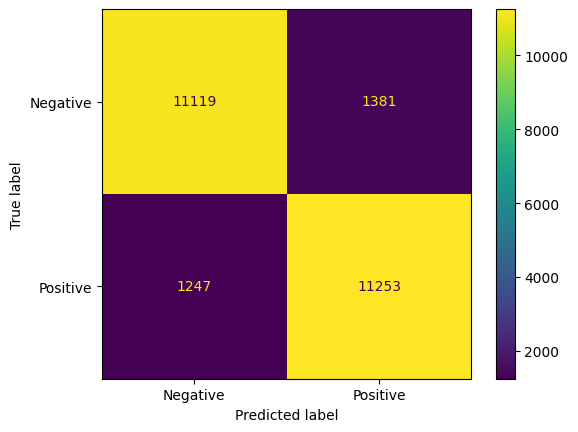

code ran for 17082.809012616 seconds


In [ ]:
Matrix = confusion_matrix(y_test,y_pred_test,labels=[0,1])
Matrix_display = ConfusionMatrixDisplay(confusion_matrix=Matrix,display_labels =["Negative","Positive"])
Matrix_display.plot()
plt.show()

end_time = time.perf_counter()
print(f"code ran for {end_time - start_time} seconds")